🚀 [全轨迹预测引擎] 17维特征(12论文+4工况+EFC) → 容量

剔除 2 块坏样本: [159, 432]
特征: 12论文 + 4工况 + EFC = 17维输入
训练 62 块 / 测试 15 块(分层盲测)
训练点 1214 / 测试点 282

⚙️  训练 SVR...
   [SVR] 测试 RMSE=0.0329 MAE=0.0207 R2=0.866
🧠 训练 DNN...
   [DNN] 测试 RMSE=0.0320 MAE=0.0208 R2=0.873


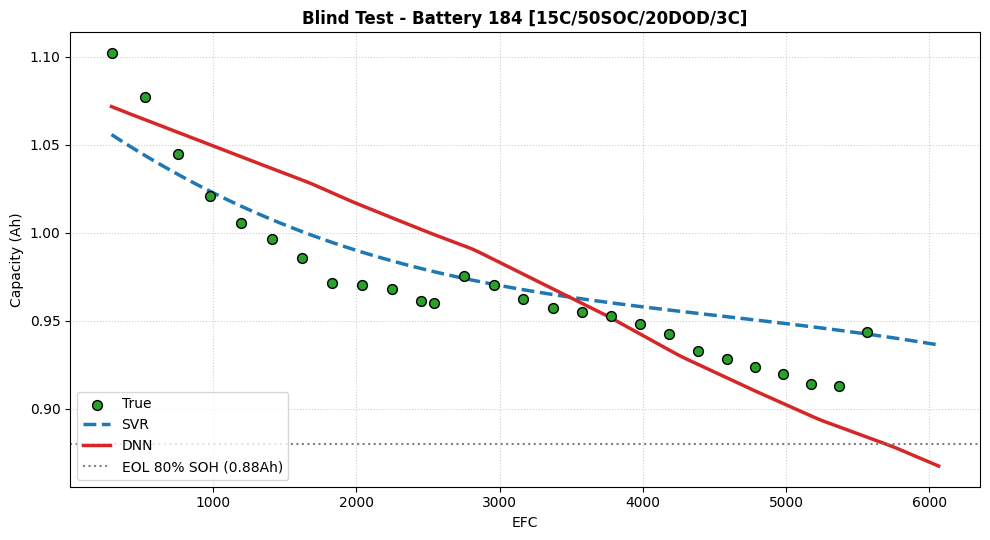


🔋 电池[184] 15C/50SOC/20DOD/3C 对账表:
EFC     |True     |SVR      |DNN      
289     |1.1022   |1.0558   |1.0717   
1409    |0.9966   |1.0075   |1.0365   
2453    |0.9614   |0.9797   |1.0019   
3370    |0.9570   |0.9649   |0.9682   
4386    |0.9328   |0.9542   |0.9252   
5566    |0.9438   |0.9424   |0.8838   


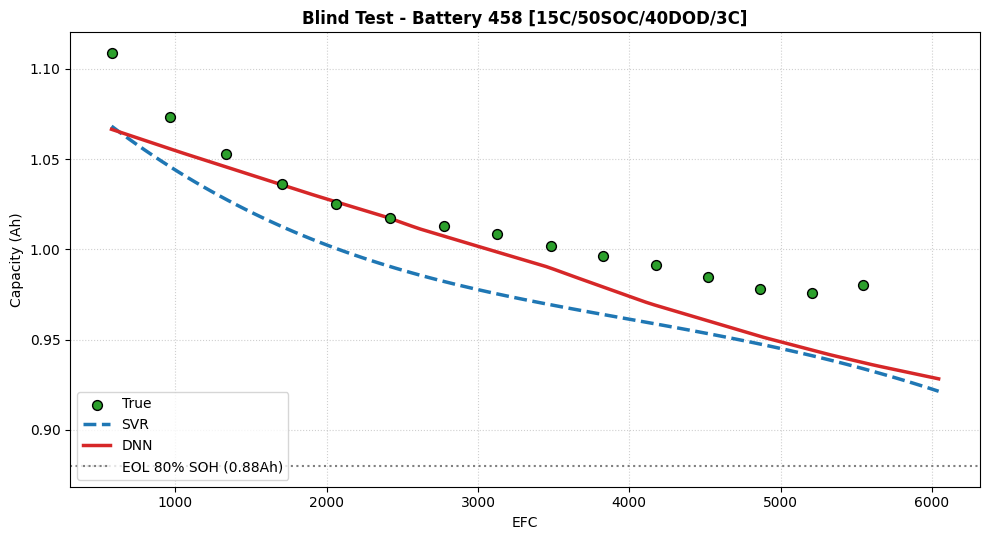


🔋 电池[458] 15C/50SOC/40DOD/3C 对账表:
EFC     |True     |SVR      |DNN      
578     |1.1088   |1.0683   |1.0665   
1338    |1.0527   |1.0276   |1.0456   
2422    |1.0175   |0.9905   |1.0171   
3480    |1.0021   |0.9694   |0.9897   
4521    |0.9845   |0.9533   |0.9604   
5545    |0.9801   |0.9340   |0.9373   


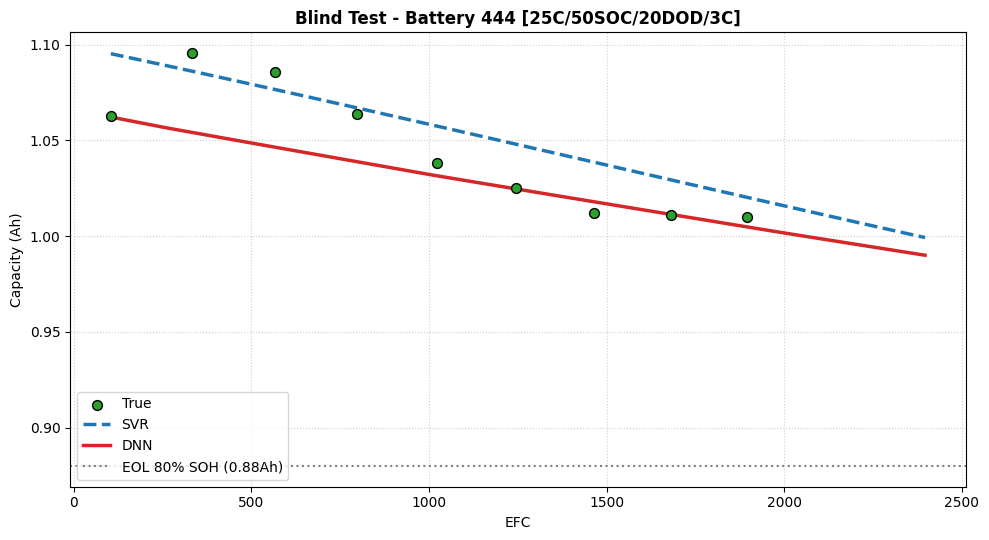


🔋 电池[444] 25C/50SOC/20DOD/3C 对账表:
EFC     |True     |SVR      |DNN      
105     |1.0626   |1.0952   |1.0622   
332     |1.0956   |1.0862   |1.0542   
797     |1.0637   |1.0670   |1.0389   
1024    |1.0384   |1.0574   |1.0315   
1464    |1.0120   |1.0386   |1.0180   
1896    |1.0098   |1.0202   |1.0048   

💾 已保存: traj_scaler.pkl / traj_svr.pkl / traj_dnn.pth


In [1]:
"""
全轨迹容量预测 —— SVR + DNN 并行 (跨工况版)

输入: 17维 = 12论文特征 + 4工况特征(temp/soc/dod/crate) + 查询EFC
输出: 该EFC处的容量(Ah)
切分: 按 温度×DOD 分层留出~15块电池做盲测(防数据泄漏:按电池切,不打乱散点)
"""
import warnings, json
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
warnings.filterwarnings("ignore")

print("🚀 [全轨迹预测引擎] 17维特征(12论文+4工况+EFC) → 容量\n")

# ==========================================
# 1. 读数据 + 清洗 + 特征列
# ==========================================
df = pd.read_csv("LFP_Final_80.csv")   # 读原始80块
# 当场清洗:剔除坏温度值(159)、坏放电时间(159)、短轨迹(432)
df['npts'] = df.Y_Trajectory.apply(lambda s: len(json.loads(s)))
bad = (df['F35_min_temp_diff'].abs()>10) | (df['F8_discharge_time_diff']>5000) | (df['npts']<8)
print(f"剔除 {bad.sum()} 块坏样本: {df[bad]['Battery_ID'].tolist()}")
df = df[~bad].drop(columns=['npts']).reset_index(drop=True)

f_cols = [c for c in df.columns if c.startswith('F')]          # 12个论文特征
cond_cols = ['cond_temp','cond_soc','cond_dod','cond_crate']    # 4个工况特征
feat_cols = f_cols + cond_cols                                  # 16个,+EFC=17维
INPUT_DIM = len(feat_cols) + 1
print(f"特征: {len(f_cols)}论文 + {len(cond_cols)}工况 + EFC = {INPUT_DIM}维输入")

# ==========================================
# 2. 按 温度×DOD 分层切分(按电池ID,防泄漏)
# ==========================================
df['strat'] = df['cond_temp'].astype(str)+'_'+df['cond_dod'].astype(str)
np.random.seed(42)
test_ids = []
for key, grp in df.groupby('strat'):
    ids = grp['Battery_ID'].tolist()
    k = round(len(ids)*0.2)
    if k >= 1:
        test_ids += list(np.random.choice(ids, k, replace=False))
train_ids = [b for b in df['Battery_ID'] if b not in test_ids]
print(f"训练 {len(train_ids)} 块 / 测试 {len(test_ids)} 块(分层盲测)")

def flatten(ids):
    """展平:每块电池的(12+4特征)与轨迹里每个EFC点拼成一行 → 容量"""
    X, y = [], []
    for b in ids:
        row = df[df.Battery_ID==b].iloc[0]
        feats = row[feat_cols].values.astype(float)
        for efc, cap in json.loads(row['Y_Trajectory']).items():
            X.append(np.append(feats, float(efc)))
            y.append(float(cap))
    return np.array(X), np.array(y)

X_train, y_train = flatten(train_ids)
X_test,  y_test  = flatten(test_ids)
print(f"训练点 {len(X_train)} / 测试点 {len(X_test)}")

scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

# ==========================================
# 3. 训练 SVR
# ==========================================
print("\n⚙️  训练 SVR...")
svr = SVR(kernel='rbf', C=30, epsilon=0.005).fit(Xtr_s, y_train)
svr_pred = svr.predict(Xte_s)
print(f"   [SVR] 测试 RMSE={np.sqrt(mean_squared_error(y_test,svr_pred)):.4f} "
      f"MAE={mean_absolute_error(y_test,svr_pred):.4f} R2={r2_score(y_test,svr_pred):.3f}")

# ==========================================
# 4. 训练 DNN
# ==========================================
print("🧠 训练 DNN...")
class TrajectoryDNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64,32), nn.ReLU(),
            nn.Linear(32,1))
    def forward(self,x): return self.net(x)

dnn = TrajectoryDNN(INPUT_DIM)
opt = optim.Adam(dnn.parameters(), lr=0.005, weight_decay=1e-4)
crit = nn.MSELoss()
Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
dnn.train()
for ep in range(800):
    opt.zero_grad(); loss = crit(dnn(Xtr_t), ytr_t); loss.backward(); opt.step()
dnn.eval()
with torch.no_grad():
    dnn_pred = dnn(torch.tensor(Xte_s,dtype=torch.float32)).numpy().flatten()
print(f"   [DNN] 测试 RMSE={np.sqrt(mean_squared_error(y_test,dnn_pred)):.4f} "
      f"MAE={mean_absolute_error(y_test,dnn_pred):.4f} R2={r2_score(y_test,dnn_pred):.3f}")

# ==========================================
# 5. 盲测电池整条轨迹预测 + 画图 + 对账表
# ==========================================
def predict_plot(b_id):
    row = df[df.Battery_ID==b_id].iloc[0]
    feats = row[feat_cols].values.astype(float)
    traj = json.loads(row['Y_Trajectory'])
    true_efc = np.array([float(k) for k in traj]); true_cap = np.array([float(v) for v in traj.values()])

    dense = np.linspace(true_efc.min(), true_efc.max()+500, 100)
    Xq = scaler.transform(np.array([np.append(feats,e) for e in dense]))
    svr_c = svr.predict(Xq)
    with torch.no_grad():
        dnn_c = dnn(torch.tensor(Xq,dtype=torch.float32)).numpy().flatten()

    plt.figure(figsize=(10,5.5))
    plt.scatter(true_efc, true_cap, c='#2ca02c', s=50, edgecolor='k', label='True', zorder=5)
    plt.plot(dense, svr_c, '--', c='#1f77b4', lw=2.5, label='SVR')
    plt.plot(dense, dnn_c, '-',  c='#d62728', lw=2.5, label='DNN')
    plt.axhline(0.88, color='gray', ls=':', label='EOL 80% SOH (0.88Ah)')
    cond = f"{row.cond_temp:.0f}C/{row.cond_soc:.0f}SOC/{row.cond_dod:.0f}DOD/{row.cond_crate:.0f}C"
    plt.title(f"Blind Test - Battery {b_id} [{cond}]", fontweight='bold')
    plt.xlabel("EFC"); plt.ylabel("Capacity (Ah)"); plt.legend(loc='lower left')
    plt.grid(True, ls=':', alpha=0.6); plt.tight_layout(); plt.show()

    print(f"\n🔋 电池[{b_id}] {cond} 对账表:")
    print(f"{'EFC':<8}|{'True':<9}|{'SVR':<9}|{'DNN':<9}")
    for i in np.linspace(0,len(true_efc)-1,6).astype(int):
        xq = scaler.transform([np.append(feats,true_efc[i])])
        sp = svr.predict(xq)[0]; dp = dnn(torch.tensor(xq,dtype=torch.float32)).item()
        print(f"{int(true_efc[i]):<8}|{true_cap[i]:<9.4f}|{sp:<9.4f}|{dp:<9.4f}")

for b in test_ids[:3]:
    predict_plot(b)

# ==========================================
# 6. 保存
# ==========================================
joblib.dump(scaler,'traj_scaler.pkl'); joblib.dump(svr,'traj_svr.pkl')
torch.save(dnn.state_dict(),'traj_dnn.pth')
print("\n💾 已保存: traj_scaler.pkl / traj_svr.pkl / traj_dnn.pth")

77块全有寿命标签 | 寿命范围 1885~11512EFC
可疑截断样本(末SOH≥90%): 13块(已验证保留它们训练效果更好)

[SVR寿命] RMSE=2415EFC MAPE=19.7% R2=0.193
[DNN寿命] RMSE=2154EFC MAPE=20.5% R2=0.358


C:\Users\zho-xli\AppData\Local\Temp\ipykernel_43388\3894418120.py:110: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_43388\3894418120.py:110: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_43388\3894418120.py:110: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_43388\3894418120.py:110: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_43388\3894418120.py:110: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zho-xli\App

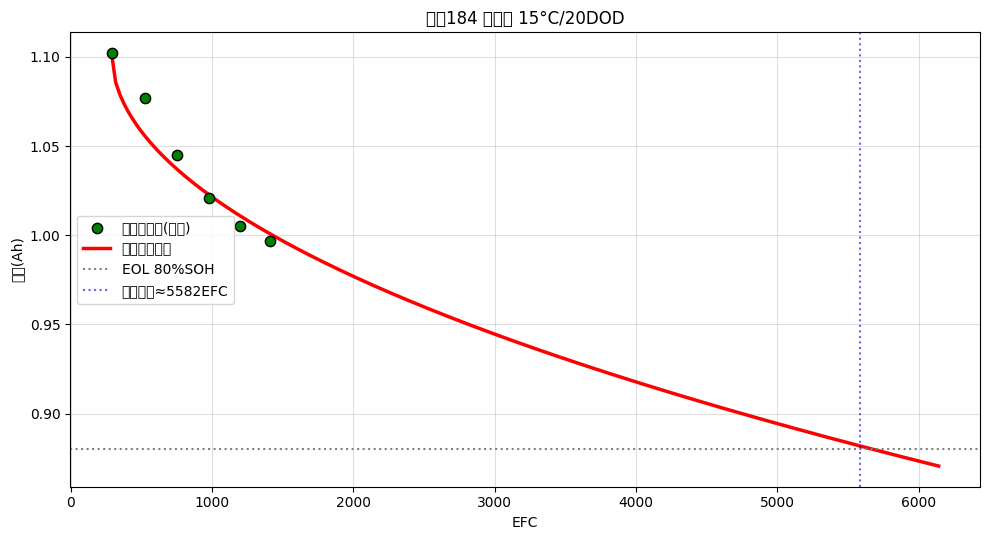

电池184: 预测寿命≈5582EFC

已保存 life_scaler.pkl / life_svr.pkl / life_dnn.pth


In [3]:
"""
两步法:论文式寿命预测 + 退化模型连曲线
  第一步: 12论文特征+4工况 → 预测寿命(到80%SOH的EFC)。一块电池一个样本(论文用法)
  第二步: 用早期实测点 + 预测寿命点,拟合平方根退化模型,画整条SOH曲线
"""
import json, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from scipy.optimize import curve_fit
import joblib

NOMINAL=1.1; EOL=0.88            # 80%SOH
df = pd.read_csv("LFP_Final_80.csv")   # ← 换成你最新的EFC-anchor版

# ============ 寿命标签:轨迹最后一个EFC(真实测试终点),77块全用 ============
def last_efc(traj_json):
    traj=json.loads(traj_json)
    return float(np.array([float(k) for k in traj]).max())
def last_soh(traj_json):
    traj=json.loads(traj_json)
    efc=np.array([float(k) for k in traj]); cap=np.array([float(v) for v in traj.values()])
    return cap[np.argmax(efc)]/NOMINAL*100

df['lifetime']=df['Y_Trajectory'].apply(last_efc)
df['末SOH']=df['Y_Trajectory'].apply(last_soh)
df['可疑截断']=df['末SOH']>=90   # 末SOH仍高,可能测试提前截止,标记备查
print(f"77块全有寿命标签 | 寿命范围 {int(df.lifetime.min())}~{int(df.lifetime.max())}EFC")
print(f"可疑截断样本(末SOH≥90%): {df['可疑截断'].sum()}块(已验证保留它们训练效果更好)")

f_cols=[c for c in df.columns if c.startswith('F')]
feat_cols=f_cols+['cond_temp','cond_soc','cond_dod','cond_crate']

# ============ 第一步:寿命预测(论文用法,一块电池一样本) ============
train_df=df.reset_index(drop=True)   # 77块全用
train_df['strat']=train_df['cond_temp'].astype(str)+'_'+train_df['cond_dod'].astype(str)
np.random.seed(42); test_idx=[]
for k,g in train_df.groupby('strat'):
    ids=g.index.tolist(); n=round(len(ids)*0.2)
    if n>=1: test_idx+=list(np.random.choice(ids,n,replace=False))
tr=train_df.drop(index=test_idx); te=train_df.loc[test_idx]
Xtr,ytr=tr[feat_cols].values,tr['lifetime'].values
Xte,yte=te[feat_cols].values,te['lifetime'].values

scaler=StandardScaler().fit(Xtr)
svr=SVR(kernel='rbf',C=5000,epsilon=30).fit(scaler.transform(Xtr),ytr)
svr_pred=svr.predict(scaler.transform(Xte))
print(f"\n[SVR寿命] RMSE={np.sqrt(mean_squared_error(yte,svr_pred)):.0f}EFC "
      f"MAPE={mean_absolute_percentage_error(yte,svr_pred)*100:.1f}% R2={r2_score(yte,svr_pred):.3f}")

# DNN寿命预测
class LifeDNN(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,64),nn.ReLU(),nn.Dropout(0.1),
                               nn.Linear(64,32),nn.ReLU(),nn.Linear(32,1))
    def forward(self,x): return self.net(x)
dnn=LifeDNN(len(feat_cols))
opt=optim.Adam(dnn.parameters(),lr=0.01,weight_decay=1e-4); crit=nn.MSELoss()
# 寿命数值大,标准化y帮助训练
ym,ys=ytr.mean(),ytr.std()
Xt=torch.tensor(scaler.transform(Xtr),dtype=torch.float32)
yt=torch.tensor((ytr-ym)/ys,dtype=torch.float32).view(-1,1)
dnn.train()
for _ in range(1500):
    opt.zero_grad(); loss=crit(dnn(Xt),yt); loss.backward(); opt.step()
dnn.eval()
with torch.no_grad():
    dnn_pred=(dnn(torch.tensor(scaler.transform(Xte),dtype=torch.float32)).numpy().flatten()*ys+ym)
print(f"[DNN寿命] RMSE={np.sqrt(mean_squared_error(yte,dnn_pred)):.0f}EFC "
      f"MAPE={mean_absolute_percentage_error(yte,dnn_pred)*100:.1f}% R2={r2_score(yte,dnn_pred):.3f}")

# ============ 第二步:退化模型连曲线 ============
# 平方根退化模型 SOH(EFC) = C0 - k*sqrt(EFC)。用早期点+预测寿命点拟合k
def plot_degradation(bid):
    row=df[df['Battery_ID']==bid].iloc[0]
    traj=json.loads(row['Y_Trajectory'])
    efc=np.array([float(k) for k in traj]); cap=np.array([float(v) for v in traj.values()])
    o=np.argsort(efc); efc,cap=efc[o],cap[o]

    # 只用早期点(SOH≥90%)当"已知",模拟早期预测场景
    early_mask=cap>=0.90*NOMINAL
    e_efc,e_cap=efc[early_mask],cap[early_mask]
    if len(e_efc)<2: e_efc,e_cap=efc[:3],cap[:3]

    # 第一步预测这块电池的寿命
    x16=scaler.transform([row[feat_cols].values.astype(float)])
    L_pred=float(svr.predict(x16)[0])

    # 平方根模型:用早期点 + 预测的EOL点(L_pred, 0.88)一起拟合
    C0=e_cap[0]
    def sqrt_model(x,k): return C0 - k*np.sqrt(x-e_efc[0])
    fit_x=np.append(e_efc, L_pred); fit_y=np.append(e_cap, EOL)
    try:
        k,_=curve_fit(sqrt_model, fit_x, fit_y, p0=[0.001])
        k=k[0]
    except: k=0.001
    dense=np.linspace(e_efc[0], L_pred*1.1, 200)
    curve=sqrt_model(dense,k)

    plt.figure(figsize=(10,5.5))
    plt.scatter(e_efc,e_cap,c='g',s=55,edgecolor='k',label='早期实测点(已知)',zorder=5)
    plt.plot(dense,curve,'-',c='r',lw=2.5,label='退化模型曲线')
    plt.axhline(EOL,color='gray',ls=':',label='EOL 80%SOH')
    plt.axvline(L_pred,color='b',ls=':',alpha=0.6,label=f'预测寿命≈{L_pred:.0f}EFC')
    plt.title(f"电池{bid} 两步法 {row.cond_temp:.0f}°C/{row.cond_dod:.0f}DOD")
    plt.xlabel("EFC"); plt.ylabel("容量(Ah)"); plt.legend(); plt.grid(alpha=.4)
    plt.tight_layout(); plt.show()
    print(f"电池{bid}: 预测寿命≈{L_pred:.0f}EFC")

# 示例:画测试集第一块的退化曲线
plot_degradation(te.iloc[0]['Battery_ID'])

joblib.dump(scaler,'life_scaler.pkl'); joblib.dump(svr,'life_svr.pkl')
torch.save(dnn.state_dict(),'life_dnn.pth')
print("\n已保存 life_scaler.pkl / life_svr.pkl / life_dnn.pth")